<a href="https://colab.research.google.com/github/Redcoder815/Machine_learning_phitron/blob/main/23TheBigCityProblem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

19. A trip duration of 86,400 seconds (24 hours) exists in this dataset. Is this a
data entry error, a real event, or something else? How would you decide
programmatically AND using domain knowledge?
20. After removing outliers from the training set, should you also remove
outliers from the test set? Justify your answer carefully — think about what a
test set represents in a real production scenario.

 Practical

21. Load the dataset (sample 20k rows). Convert 'pickup_datetime' to datetime
and extract hour, day-of-week, and month as new features. Check: are there any
biologically impossible trip durations (e.g., <= 0 seconds or > 24 hours)?

22. Apply IQR-based outlier detection to 'trip_duration'. Print how many
outliers were detected and what % of the data they represent. Remove them
from the training set ONLY.

23. Create a scatter plot of pickup_longitude vs pickup_latitude, coloring points
by trip_duration. Do the outlier trips cluster in any particular geographic area?
What does that suggest?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/train.csv')
df

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435
...,...,...,...,...,...,...,...,...,...,...,...
1458639,id2376096,2,2016-04-08 13:31:04,2016-04-08 13:44:02,4,-73.982201,40.745522,-73.994911,40.740170,N,778
1458640,id1049543,1,2016-01-10 07:35:15,2016-01-10 07:46:10,1,-74.000946,40.747379,-73.970184,40.796547,N,655
1458641,id2304944,2,2016-04-22 06:57:41,2016-04-22 07:10:25,1,-73.959129,40.768799,-74.004433,40.707371,N,764
1458642,id2714485,1,2016-01-05 15:56:26,2016-01-05 16:02:39,1,-73.982079,40.749062,-73.974632,40.757107,N,373


A trip duration of exactly 86,400 seconds (24 hours) is "something else"—specifically a system timeout limit or an unclosed meter bug, rather than a real trip or a manual data entry typo. The recording system automatically truncates stuck rides at this exact 24-hour mark.

Analysis Using Domain Knowledge

System Caps: NYC taxi meters have a hard software timeout.Open Meters: Drivers occasionally forget to turn off meters.Shift Limits: TLC regulations restrict continuous driver shifts.Fuel Limits: Standard yellow cabs cannot drive 24 hours continuously.NYC Geography: No realistic trip within boroughs takes a full day.

Programmatic Validation Steps1. Calculate Average SpeedCompute the average speed for the trip. Use trip distance divided by trip duration. A speed near 0 mph points to a stationary vehicle.2. Measure Coordinates DistanceCalculate the Haversine distance between pickup and drop-off. Identical or near-identical coordinates confirm the taxi never moved.3. Check Distribution SpikesPlot a histogram of long trip durations. A sudden, sharp spike exactly at 86,400 seconds indicates a system-enforced truncation ceiling.4. Verify Datetime MathSubtract the pickup timestamp from the drop-off timestamp. Confirm if it equals exactly 86,400 seconds.

No, you should generally not remove outliers from the test set.The test set must mimic real-world production data, which naturally contains noise, system anomalies, and extreme values. Altering it creates a false, overly optimistic measure of performance.

Why the Test Set Must Keep Outliers

1. Simulating Production RealityReal-world incoming data is inherently messy and unpredictable.Your model in production will encounter these exact same anomalies.Testing on an artificially cleaned dataset hides how your model handles real failures.

2. Evaluating Model RobustnessIt is critical to know how extreme values skew your model's predictions.Keeping outliers reveals if your model fails catastrophically or gracefully.

3. Preventing Data Leakage and BiasRemoving data points requires defining outlier thresholds (e.g., using training set statistics).Applying these thresholds to the test set introduces data leakage.

The Only Exception: Production Pipeline Pre-filteringYou may remove outliers from the test set only if you deploy a hard coded upstream data-validation pipeline in production that automatically blocks or drops these specific records before they ever reach the model.Example: If your production system drops any trip recorded at exactly 24 hours before making a prediction, you can remove them from the test set.Rule: If the production model is forced to make a prediction on it, it must remain in your test set.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


In [4]:
df = pd.read_csv('/content/train.csv', nrows = 20000)
df

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435
...,...,...,...,...,...,...,...,...,...,...,...
19995,id3263883,1,2016-03-10 17:30:01,2016-03-10 17:46:48,1,-73.972504,40.756508,-73.980820,40.761787,N,1007
19996,id2600174,2,2016-02-08 19:54:02,2016-02-08 20:11:58,1,-74.007507,40.726292,-73.967369,40.788616,N,1076
19997,id3433340,1,2016-03-17 11:46:18,2016-03-17 11:57:11,1,-73.984177,40.761471,-73.990601,40.751087,N,653
19998,id2596866,1,2016-06-01 17:22:09,2016-06-01 17:38:44,1,-73.995407,40.749489,-73.984955,40.769161,N,995


In [5]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

In [6]:
df['hour'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek
df['month'] = df['pickup_datetime'].dt.month

In [7]:
imporssible_zero_negative = df[df['trip_duration'] <= 0]
impossible_too_long = df[df['trip_duration'] >= 86400]

print(len(imporssible_zero_negative))
display(imporssible_zero_negative)

0


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,day_of_week,month


In [8]:
display(impossible_too_long)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,day_of_week,month


In [9]:
trip_Q1 = df['trip_duration'].quantile(0.25)
trip_Q3 = df['trip_duration'].quantile(0.75)

trip_IQR = trip_Q3 - trip_Q1

trip_minimum = max(0,trip_Q1 - 1.5 * trip_IQR)
trip_maximum = trip_Q3 + 1.5 * trip_IQR

print(trip_minimum , trip_maximum)

0 2067.5


In [10]:
trip_outlier_IQR = df[(df['trip_duration']<trip_minimum) | (df['trip_duration']>trip_maximum)]

print(len(trip_outlier_IQR))
display(trip_outlier_IQR)

1005


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,day_of_week,month
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,11,1,1
16,id3379579,2,2016-04-11 17:29:50,2016-04-11 18:08:26,1,-73.991165,40.755562,-73.999290,40.725353,N,2316,17,0,4
24,id3321406,2,2016-06-03 08:15:05,2016-06-03 08:56:30,1,-73.955231,40.777134,-73.788750,40.641472,N,2485,8,4,6
29,id1410897,1,2016-03-23 14:10:39,2016-03-23 14:49:30,1,-73.982117,40.756351,-73.865692,40.770988,N,2331,14,2,3
33,id0023813,1,2016-04-17 14:38:30,2016-04-17 15:16:19,1,-73.990311,40.756580,-73.870918,40.773930,N,2269,14,6,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19852,id0657019,2,2016-03-24 10:34:38,2016-03-24 11:19:06,1,-73.782005,40.644711,-74.013832,40.628796,N,2668,10,3,3
19861,id1674523,2,2016-06-09 19:08:28,2016-06-09 19:59:07,1,-73.788651,40.641479,-73.977394,40.683868,N,3039,19,3,6
19876,id2953736,1,2016-01-29 07:45:06,2016-01-29 09:07:52,1,-73.776672,40.645432,-74.006042,40.739937,N,4966,7,4,1
19905,id0900935,2,2016-03-29 16:24:29,2016-03-29 17:32:06,1,-73.807449,40.656731,-74.004578,40.707291,N,4057,16,1,3


In [11]:
percentage_of_outliers = (len(trip_outlier_IQR)/len(df)) * 100

print(percentage_of_outliers)

5.025


In [12]:
df1 = df[(df['trip_duration'] >= trip_minimum) & (df['trip_duration'] <= trip_maximum)]
df1['trip_duration'].max()

2066

In [13]:
df['trip_duration']= df['trip_duration'].clip(trip_minimum , trip_maximum)
df['trip_duration'].max()

2067.5

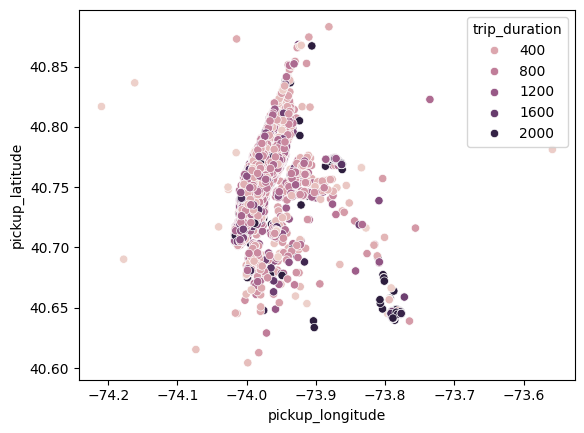

In [14]:
sns.scatterplot(data = df, x = 'pickup_longitude', y = 'pickup_latitude', hue = 'trip_duration')
plt.show()

Based on the provided plot, the high-duration outlier trips (indicated by the darkest purple dots representing durations of 1600 to 2000+ seconds) do cluster in distinct geographic areas.

🗺️ Where the Outliers Cluster

Bottom-Right Cluster: Concentrated heavily around longitude -73.78 and latitude 40.65. This matches JFK Airport.Middle-Right Cluster: Grouped around longitude -73.87 and latitude 40.77. This matches LaGuardia Airport.Central Vertical Strip: Scattered heavily throughout the dense core grid between longitudes -74.01 and -73.95. This matches Manhattan.

💡 What This Suggests

1. Long-Distance Commutes

Trips originating at JFK and LaGuardia airports are inherently long-distance runs. They require highway travel to reach Manhattan or outer boroughs, leading to naturally higher baseline durations.

2. Severe Traffic Gridlock

The high-duration clusters inside Manhattan suggest dense urban traffic. Taxis in these zones experience extreme delays and low speeds, meaning a short physical distance requires a massive amount of time.

3. Airport Gateway Bottlenecks

The heavy density of dark points at airport terminals highlights systemic queuing delays. Construction, passenger pickup bottlenecks, and airport exit traffic significantly inflate total trip duration.